### Histogram Equilization

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [6]:
gray_img = cv2.imread('misc/house.tiff', 0)

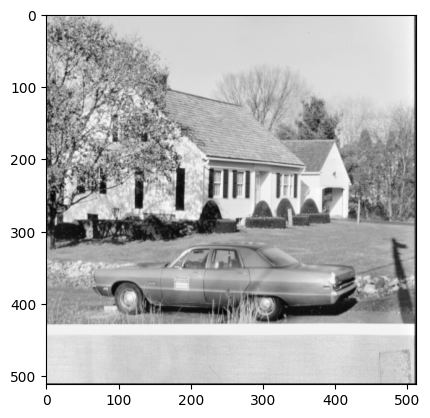

In [7]:
gray_img_plot = plt.imshow(gray_img, cmap='gray')

In [12]:
L = 256 # 8 bit image

In [20]:
# Calculate frequency of input intensities

r = list() # r is input intensity
m, n = gray_img.shape

for intensity in range(L):
    count = 0
    for i in range(m):
        for j in range(n):
            if gray_img[i][j] == intensity:
                count = count + 1
    r.append(count)

print(r)

[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 4, 7, 9, 15, 30, 51, 79, 129, 202, 306, 441, 530, 585, 558, 546, 501, 456, 405, 349, 338, 301, 286, 280, 272, 238, 243, 233, 247, 211, 199, 222, 225, 228, 200, 204, 227, 208, 194, 225, 212, 219, 245, 260, 259, 291, 292, 358, 373, 439, 423, 493, 456, 451, 457, 409, 423, 377, 366, 350, 380, 400, 404, 428, 403, 452, 448, 450, 446, 452, 467, 427, 472, 462, 440, 466, 448, 532, 527, 509, 495, 527, 509, 519, 545, 552, 620, 639, 666, 625, 648, 671, 672, 657, 651, 745, 673, 739, 715, 763, 779, 771, 794, 819, 856, 848, 914, 928, 956, 895, 942, 1042, 1008, 1011, 1090, 1107, 1115, 1150, 1124, 1223, 1192, 1269, 1226, 1322, 1308, 1325, 1361, 1409, 1483, 1526, 1492, 1586, 1618, 1653, 1682, 1797, 1809, 1909, 1939, 2087, 2221, 2336, 2436, 2414, 2479, 2448, 2244, 2254, 2200, 2140, 2115, 2051, 1948, 1835, 1865, 1738, 1654, 1678, 1649, 1537, 1624, 1596, 1587, 1538, 1555, 1499, 1520, 1537, 1514, 1474, 1487, 1455, 1488, 1507, 1497, 1614, 1830, 1869, 1955, 2290, 2462, 265

In [55]:
# Calculating probabilities and cumulative probabilities
prob = list()
cum_prob = list()
s = list() # Output intensity

for i in range(256):
    freq = r[i]
    probability = freq/(m*n)
    prob.append(probability)
    if i == 0:
        cum_prob.append(probability)
    else:
        cum_prob.append(cum_prob[i-1] + probability)
    s.append(round(cum_prob[i]*(L-1)))
    

In [56]:
print(s)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 10, 10, 10, 10, 11, 11, 11, 11, 12, 12, 13, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 17, 17, 18, 18, 19, 19, 20, 20, 20, 21, 21, 22, 22, 23, 23, 23, 24, 24, 25, 25, 26, 26, 27, 27, 28, 29, 29, 30, 30, 31, 32, 32, 33, 34, 34, 35, 36, 36, 37, 38, 38, 39, 40, 41, 42, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 59, 60, 61, 63, 64, 65, 67, 68, 70, 71, 73, 74, 76, 77, 79, 81, 83, 85, 87, 89, 91, 94, 96, 98, 101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 120, 122, 124, 125, 127, 128, 130, 132, 133, 135, 136, 137, 139, 140, 142, 143, 145, 146, 148, 149, 151, 152, 154, 156, 158, 161, 163, 166, 169, 172, 174, 178, 182, 187, 195, 201, 207, 212, 216, 220, 224, 227, 229, 231, 233, 234, 235, 237, 238, 238, 239, 240, 241, 242, 243, 244, 245, 246, 250, 253, 254, 254, 254, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 

In [57]:
out_img = np.zeros(shape = gray_img.shape)

In [58]:
for intensity in range(256):
    for i in range(m):
        for j in range(n):
            if gray_img[i][j] == intensity:
                out_img[i][j] = s[intensity]

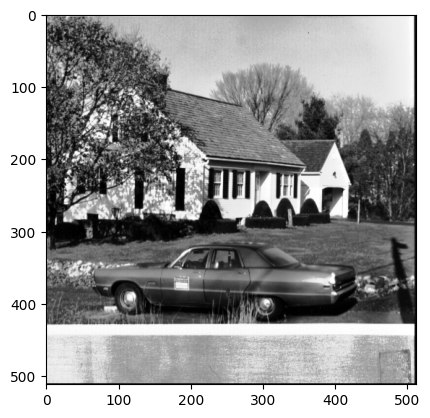

In [59]:
output_img_plot = plt.imshow(out_img, cmap='gray')

In [64]:
# Histogram
column_items = ['r', 'freq', 'p', 'c', 'S']

for item in column_items:
    print(item, end='\t\t\t\t')
print()
for i in range(256):
    print(intensity, '\t\t\t\t', r[i], '\t\t\t\t', prob[i], '\t\t\t\t', cum_prob[i], '\t\t\t\t', s[i]) 
    print()

r				freq				p				c				S				
255 				 0 				 0.0 				 0.0 				 0

255 				 0 				 0.0 				 0.0 				 0

255 				 0 				 0.0 				 0.0 				 0

255 				 0 				 0.0 				 0.0 				 0

255 				 0 				 0.0 				 0.0 				 0

255 				 0 				 0.0 				 0.0 				 0

255 				 0 				 0.0 				 0.0 				 0

255 				 0 				 0.0 				 0.0 				 0

255 				 1 				 3.814697265625e-06 				 3.814697265625e-06 				 0

255 				 0 				 0.0 				 3.814697265625e-06 				 0

255 				 0 				 0.0 				 3.814697265625e-06 				 0

255 				 1 				 3.814697265625e-06 				 7.62939453125e-06 				 0

255 				 4 				 1.52587890625e-05 				 2.288818359375e-05 				 0

255 				 7 				 2.6702880859375e-05 				 4.9591064453125e-05 				 0

255 				 9 				 3.4332275390625e-05 				 8.392333984375e-05 				 0

255 				 15 				 5.7220458984375e-05 				 0.000141143798828125 				 0

255 				 30 				 0.00011444091796875 				 0.000255584716796875 				 0

255 				 51 				 0.000194549560546875 				 0.00045013427734375 				 0

255 				 79 				 0.000